# 02 - Factor Research

This notebook reviews factor diagnostics generated by the main pipeline. It reads IC reports from `reports/` and does not recompute core factor logic.

## Current Factor Definitions

- Momentum: $\log(\frac{P_{t-skip}}{P_{t-lookback}})$. The original default is 12-1 momentum: `lookback_days=252`, `skip_days=21`.
- Low volatility: negative annualized rolling volatility of returns, so lower-volatility stocks receive higher scores.
- Short-term reversal: negative recent 1-month log return.
- Composite: equal-weight combination of cross-sectionally z-scored factors, standardized again cross-sectionally.

In [9]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

REPORTS = PROJECT_ROOT / "reports"

def read_report_csv(filename):
    path = REPORTS / filename
    if not path.exists():
        raise FileNotFoundError(f"Run python main.py first. Missing: {path}")
    return pd.read_csv(path)

## Load IC Reports

In [10]:
factor_ic = read_report_csv("factor_ic_summary.csv")
factor_ic_subperiod = read_report_csv("factor_ic_subperiod.csv")
momentum_ic = read_report_csv("momentum_ic_sensitivity.csv")

display(factor_ic)
display(factor_ic_subperiod.head())
display(momentum_ic)

,factor,mean_ic,std_ic,icir,hit_rate,count,mean_rank_ic,rank_icir,rank_hit_rate
0,momentum,0.021010,0.194769,0.107872,0.564885,131.0,0.009281,0.050050,0.534351
1,lowvol,-0.072719,0.256616,-0.283377,0.381679,131.0,-0.035185,-0.147602,0.427481
2,reversal,-0.009561,0.166557,-0.057402,0.441176,136.0,0.000303,0.001826,0.500000
3,composite,0.004114,0.200403,0.020530,0.519084,131.0,0.004105,0.021190,0.488550


,factor,period,mean_ic,icir,hit_rate,mean_rank_ic,rank_icir,rank_hit_rate,count
0,momentum,2015_2019,-0.013084,-0.068626,0.425926,-0.014651,-0.076464,0.425926,54.0
1,momentum,2020_2022,0.024460,0.105860,0.638889,0.020107,0.093235,0.611111,36.0
2,momentum,2023_latest,0.062885,0.397462,0.682927,0.031297,0.215734,0.609756,41.0
3,lowvol,2015_2019,-0.057933,-0.280013,0.351852,-0.023077,-0.101331,0.444444,54.0
4,lowvol,2020_2022,-0.035601,-0.115727,0.500000,-0.030423,-0.112070,0.444444,36.0


,lookback_days,skip_days,mean_ic,std_ic,icir,hit_rate,count,mean_rank_ic,rank_icir,rank_hit_rate
0,63,0,0.005562,0.191658,0.029019,0.529851,134.0,-0.002122,-0.011566,0.500000
1,63,21,-0.004418,0.179574,-0.024603,0.514925,134.0,-0.007184,-0.040958,0.485075
2,126,0,0.021010,0.194769,0.107872,0.564885,131.0,0.009281,0.050050,0.534351
3,126,21,0.016941,0.185815,0.091173,0.526718,131.0,0.004836,0.026834,0.480916
4,189,0,0.020137,0.212458,0.094783,0.570312,128.0,0.007590,0.037865,0.546875
5,189,21,0.017750,0.204526,0.086786,0.546875,128.0,0.004980,0.025549,0.515625
6,252,0,0.016907,0.212743,0.079471,0.552000,125.0,0.002586,0.012765,0.544000
7,252,21,0.015338,0.203740,0.075281,0.560000,125.0,0.001472,0.007473,0.536000


## Sort Factors by IC and Rank IC

In [11]:
display(factor_ic.sort_values("mean_ic", ascending=False))
display(factor_ic.sort_values("mean_rank_ic", ascending=False))

,factor,mean_ic,std_ic,icir,hit_rate,count,mean_rank_ic,rank_icir,rank_hit_rate
0,momentum,0.021010,0.194769,0.107872,0.564885,131.0,0.009281,0.050050,0.534351
3,composite,0.004114,0.200403,0.020530,0.519084,131.0,0.004105,0.021190,0.488550
2,reversal,-0.009561,0.166557,-0.057402,0.441176,136.0,0.000303,0.001826,0.500000
1,lowvol,-0.072719,0.256616,-0.283377,0.381679,131.0,-0.035185,-0.147602,0.427481


,factor,mean_ic,std_ic,icir,hit_rate,count,mean_rank_ic,rank_icir,rank_hit_rate
0,momentum,0.021010,0.194769,0.107872,0.564885,131.0,0.009281,0.050050,0.534351
3,composite,0.004114,0.200403,0.020530,0.519084,131.0,0.004105,0.021190,0.488550
2,reversal,-0.009561,0.166557,-0.057402,0.441176,136.0,0.000303,0.001826,0.500000
1,lowvol,-0.072719,0.256616,-0.283377,0.381679,131.0,-0.035185,-0.147602,0.427481


## Factor IC Bar Plots

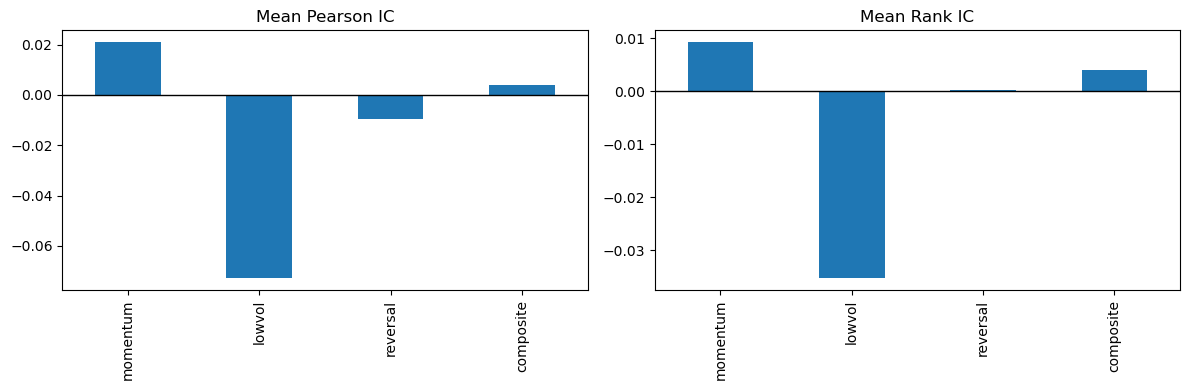

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

factor_ic.set_index("factor")["mean_ic"].plot(kind="bar", ax=axes[0], title="Mean Pearson IC")
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_xlabel("")

factor_ic.set_index("factor")["mean_rank_ic"].plot(kind="bar", ax=axes[1], title="Mean Rank IC")
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_xlabel("")

plt.tight_layout()
plt.show()

## Momentum Parameter Sensitivity

In [13]:
display(momentum_ic.sort_values("mean_ic", ascending=False))

mean_ic_pivot = momentum_ic.pivot(index="lookback_days", columns="skip_days", values="mean_ic")
rank_ic_pivot = momentum_ic.pivot(index="lookback_days", columns="skip_days", values="mean_rank_ic")

print("Mean Pearson IC by momentum parameters")
display(mean_ic_pivot)

print("Mean Rank IC by momentum parameters")
display(rank_ic_pivot)

,lookback_days,skip_days,mean_ic,std_ic,icir,hit_rate,count,mean_rank_ic,rank_icir,rank_hit_rate
2,126,0,0.021010,0.194769,0.107872,0.564885,131.0,0.009281,0.050050,0.534351
4,189,0,0.020137,0.212458,0.094783,0.570312,128.0,0.007590,0.037865,0.546875
5,189,21,0.017750,0.204526,0.086786,0.546875,128.0,0.004980,0.025549,0.515625
3,126,21,0.016941,0.185815,0.091173,0.526718,131.0,0.004836,0.026834,0.480916
6,252,0,0.016907,0.212743,0.079471,0.552000,125.0,0.002586,0.012765,0.544000
7,252,21,0.015338,0.203740,0.075281,0.560000,125.0,0.001472,0.007473,0.536000
0,63,0,0.005562,0.191658,0.029019,0.529851,134.0,-0.002122,-0.011566,0.500000
1,63,21,-0.004418,0.179574,-0.024603,0.514925,134.0,-0.007184,-0.040958,0.485075


Mean Pearson IC by momentum parameters


skip_days,0,21
lookback_days,,
63,0.005562,-0.004418
126,0.021010,0.016941
189,0.020137,0.017750
252,0.016907,0.015338


Mean Rank IC by momentum parameters


skip_days,0,21
lookback_days,,
63,-0.002122,-0.007184
126,0.009281,0.004836
189,0.007590,0.004980
252,0.002586,0.001472


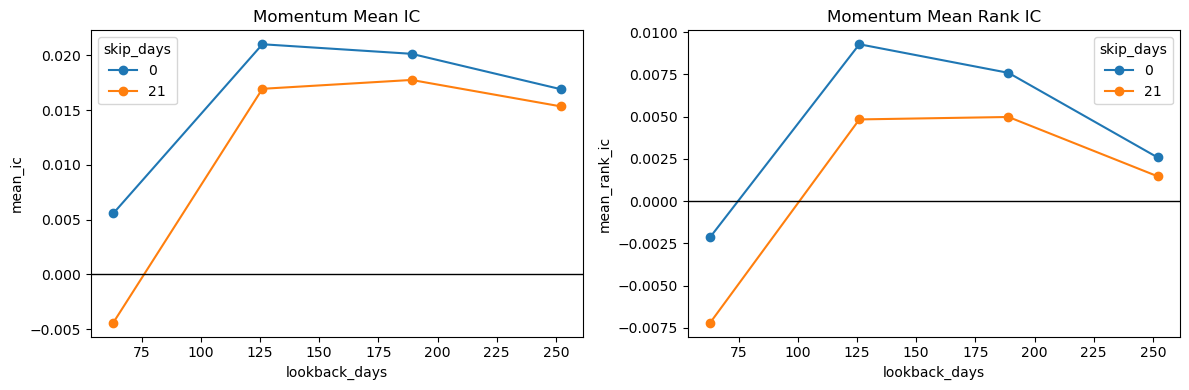

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
mean_ic_pivot.plot(marker="o", ax=axes[0], title="Momentum Mean IC")
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_ylabel("mean_ic")

rank_ic_pivot.plot(marker="o", ax=axes[1], title="Momentum Mean Rank IC")
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_ylabel("mean_rank_ic")

plt.tight_layout()
plt.show()

## Momentum Parameter Sensitivity: IC vs Backtest

This section compares momentum parameter evidence from two angles: cross-sectional IC diagnostics and full backtest sensitivity. Both are useful, but they answer different questions. IC measures stock ranking quality; backtest sensitivity includes portfolio construction, benchmark weights, transaction costs, and turnover.

In [15]:
momentum_ic = read_report_csv("momentum_ic_sensitivity.csv")
momentum_backtest = read_report_csv("momentum_backtest_sensitivity.csv")

print("Momentum IC sensitivity sorted by mean Rank IC")
display(momentum_ic.sort_values("mean_rank_ic", ascending=False))

print("Momentum backtest sensitivity sorted by information ratio")
display(momentum_backtest.sort_values("information_ratio", ascending=False))

Momentum IC sensitivity sorted by mean Rank IC


,lookback_days,skip_days,mean_ic,std_ic,icir,hit_rate,count,mean_rank_ic,rank_icir,rank_hit_rate
2,126,0,0.021010,0.194769,0.107872,0.564885,131.0,0.009281,0.050050,0.534351
4,189,0,0.020137,0.212458,0.094783,0.570312,128.0,0.007590,0.037865,0.546875
5,189,21,0.017750,0.204526,0.086786,0.546875,128.0,0.004980,0.025549,0.515625
3,126,21,0.016941,0.185815,0.091173,0.526718,131.0,0.004836,0.026834,0.480916
6,252,0,0.016907,0.212743,0.079471,0.552000,125.0,0.002586,0.012765,0.544000
7,252,21,0.015338,0.203740,0.075281,0.560000,125.0,0.001472,0.007473,0.536000
0,63,0,0.005562,0.191658,0.029019,0.529851,134.0,-0.002122,-0.011566,0.500000
1,63,21,-0.004418,0.179574,-0.024603,0.514925,134.0,-0.007184,-0.040958,0.485075


Momentum backtest sensitivity sorted by information ratio


,lookback_days,skip_days,total_return,annualized_return,annualized_volatility,sharpe_ratio,max_drawdown,hit_ratio,annualized_active_return,tracking_error,information_ratio,average_turnover,annualized_turnover
2,126,0,13.829397,0.282053,0.207144,1.303912,-0.330816,0.573309,0.121516,0.055359,2.195046,0.048709,0.584504
0,63,0,13.975412,0.275915,0.204336,1.295490,-0.326908,0.571633,0.118079,0.054173,2.179662,0.068691,0.824292
3,126,21,13.528225,0.279632,0.208423,1.288107,-0.336198,0.575503,0.119889,0.055890,2.145064,0.054108,0.649299
4,189,0,13.142407,0.283950,0.206766,1.313083,-0.328400,0.577312,0.119234,0.055910,2.132613,0.040424,0.485086
1,63,21,13.501996,0.272231,0.205895,1.273181,-0.333488,0.571633,0.115505,0.054781,2.108504,0.085088,1.021051
5,189,21,12.996085,0.282691,0.207842,1.302630,-0.331551,0.577312,0.118475,0.056334,2.103058,0.043145,0.517742
6,252,0,13.481132,0.294427,0.207087,1.350646,-0.328316,0.576628,0.118007,0.056122,2.102691,0.035583,0.427000
7,252,21,13.366026,0.293430,0.208068,1.341546,-0.331145,0.577011,0.117438,0.056506,2.078331,0.037002,0.444026


In [16]:
momentum_comparison = momentum_ic.merge(
    momentum_backtest,
    on=["lookback_days", "skip_days"],
    how="inner",
)

comparison_columns = [
    "lookback_days",
    "skip_days",
    "mean_ic",
    "mean_rank_ic",
    "icir",
    "rank_icir",
    "annualized_active_return",
    "tracking_error",
    "information_ratio",
    "annualized_turnover",
]

display(
    momentum_comparison.loc[:, comparison_columns]
    .sort_values("information_ratio", ascending=False)
    .reset_index(drop=True)
)

,lookback_days,skip_days,mean_ic,mean_rank_ic,icir,rank_icir,annualized_active_return,tracking_error,information_ratio,annualized_turnover
0,126,0,0.021010,0.009281,0.107872,0.050050,0.121516,0.055359,2.195046,0.584504
1,63,0,0.005562,-0.002122,0.029019,-0.011566,0.118079,0.054173,2.179662,0.824292
2,126,21,0.016941,0.004836,0.091173,0.026834,0.119889,0.055890,2.145064,0.649299
3,189,0,0.020137,0.007590,0.094783,0.037865,0.119234,0.055910,2.132613,0.485086
4,63,21,-0.004418,-0.007184,-0.024603,-0.040958,0.115505,0.054781,2.108504,1.021051
5,189,21,0.017750,0.004980,0.086786,0.025549,0.118475,0.056334,2.103058,0.517742
6,252,0,0.016907,0.002586,0.079471,0.012765,0.118007,0.056122,2.102691,0.427000
7,252,21,0.015338,0.001472,0.075281,0.007473,0.117438,0.056506,2.078331,0.444026


The current prototype supports 126-day no-skip momentum from both IC sensitivity and backtest sensitivity: it ranks well on mean IC / Rank IC and has the strongest information ratio in the current backtest run. The 252-day momentum variants have lower turnover, so the choice is not purely about information ratio; there is a trade-off between signal responsiveness and implementation cost. These results still rely on the current static market-cap proxy when `market_cap_static` is used, which introduces look-ahead bias.

## From Factor IC to Alpha Model Design

The IC diagnostics suggest that momentum is the most promising of the current price-based factors, while low-volatility has weak or negative standalone IC and short-term reversal is unstable. That means the original equal-weight composite is useful as a baseline, but it is not necessarily the best alpha model.

Version 1.3 introduces configurable alpha models so the final score can reflect the research evidence more directly. The current default is risk-adjusted momentum:

$$\alpha_{i,t} = z(MOM_{i,t}) + 0.25 \times z(LOWVOL_{i,t})$$

This keeps momentum as the main alpha signal and uses low-volatility as a modest risk-control component rather than treating it as an equal standalone alpha factor.

## Research Conclusion

The factor IC evidence is weak overall. Momentum is the most promising of the current factors, but the original 12-1 version is not clearly the best specification. In the tested sample, 6-month no-skip momentum appears stronger than 12-1 momentum. Low-volatility and reversal have weaker or less stable IC evidence and should be handled carefully.